In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm 

In [3]:
# Importing the hdf5 snapshot file and printing relevant information
h5py_file = "C:\\Users\\aleja\\astrofisica_teorica\\sim_num\\claudio_nbody\\snapshot_000.hdf5"

with h5py.File(h5py_file, "r") as f:
    pos1 = np.asarray(f["/PartType1/Coordinates"]) # kpc/h
    pos2 = np.asarray(f["/PartType2/Coordinates"]) # kpc/h
    info = np.asarray(f["/PartType1/Velocities"]) # kpc/h
    print("---File Information---")
    print(list(f.keys()))
    print(list(f["Parameters"].keys()))
    header = f["Header"].attrs
    mass = header["MassTable"] # 1e10 Msun/h
    stellar_mass = mass[2] # 1e10 Msun/h
    print("")
    print("---Attributes in Header---")
    for key in header.keys():
        value = header[key]
        print(f"{key}: {value}")

---File Information---
['Config', 'Header', 'Parameters', 'PartType1', 'PartType2']
[]

---Attributes in Header---
BoxSize: 0.0
Git_commit: b'6e4f1128ac696260d3f2aff68cb6fa7b335e4c1c'
Git_date: b'Tue May 20 19:00:00 2025 +0200'
MassTable: [0.         0.00104634 0.00023252]
NumFilesPerSnapshot: 1
NumPart_ThisFile: [    0 40000 20000]
NumPart_Total: [    0 40000 20000]
Redshift: 0.0
Time: 0.0


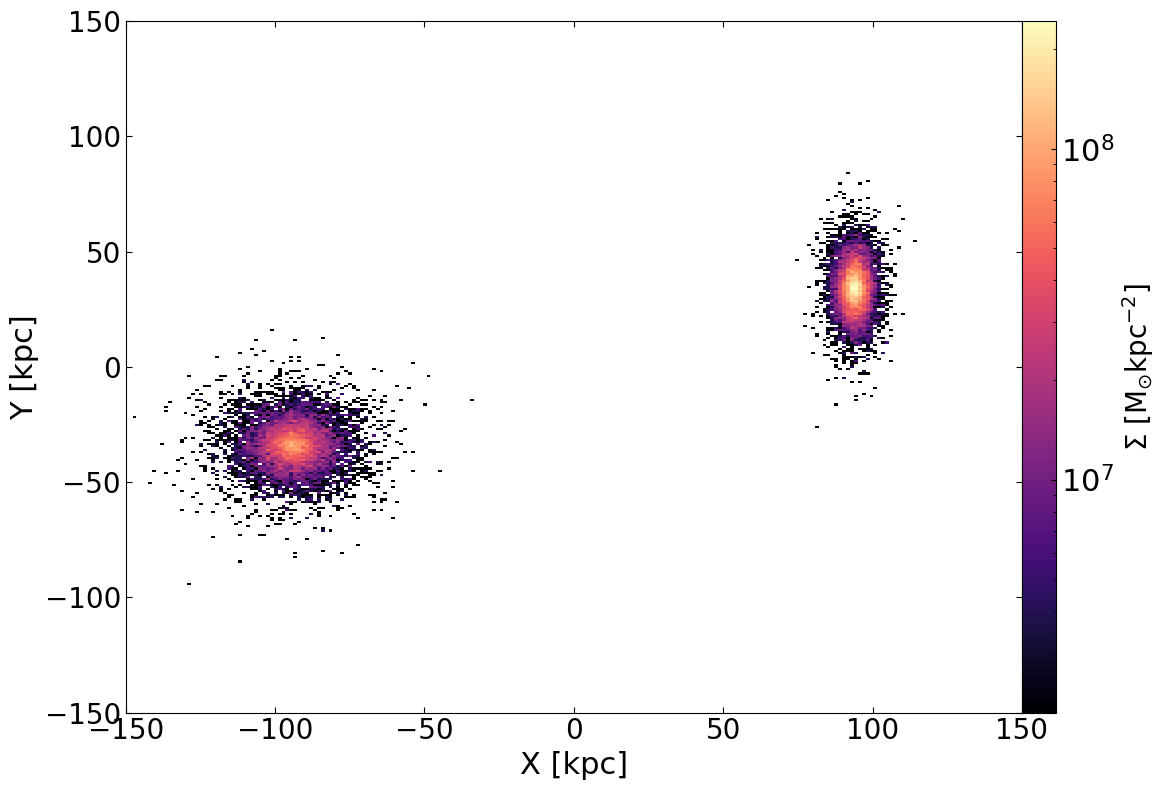

In [4]:
# Closing plots
plt.close("all")
    
# Defining the comoving parameter h and conversion factors
H_0 = 70 # km/s/Mpc (value in between Cepheids and Planck CMB measurements)
h = 1 # stated in the snapshot file (already in physical units)
mass_conv_factor = 1e10 # Msun/h

# Calculating the h scaled masses and positions
stellar_mass_phys = (stellar_mass*mass_conv_factor)/h
pos1_phys = pos1/h
pos2_phys = pos2/h

# Storing x and y positions separately (DM-type1 and Stars-type2)
xpos1 = np.zeros(len(pos1_phys))
ypos1 = np.zeros(len(pos1_phys))

xpos2 = np.zeros(len(pos2_phys))
ypos2 = np.zeros(len(pos2_phys))

for ii in range(len(pos1_phys)):
    xpos1[ii] = pos1_phys[ii][0]
    ypos1[ii] = pos1_phys[ii][1]
    
for ii in range(len(pos2_phys)):
    xpos2[ii] = pos2_phys[ii][0]
    ypos2[ii] = pos2_phys[ii][1]
    
# Plotting the histogram for the stellar mass density
nbins = 200
weights_array = np.full_like(xpos2, stellar_mass_phys)
hist, xedges, yedges = np.histogram2d(xpos2, ypos2, bins=nbins, weights=weights_array)

# Calculating the area of the bins
x_length = xedges[1] - xedges[0]
y_length = yedges[1] - yedges[0]
area = x_length*y_length # kpc^2
surf_density = hist/area # Msun/kpc^2

# Visualizing the result
fig = plt.figure(figsize=(12, 8))
plt.pcolormesh(xedges, yedges, surf_density.T, norm=LogNorm(), cmap="magma")
cbar = plt.colorbar(pad=0)
cbar.ax.tick_params(direction="in", which="both", labelsize=22)
cbar.set_label(label=r'$\Sigma$ [$\rm{M}_{\odot} \text{kpc}^{-2}$]', fontsize=20)
plt.tick_params(direction="in", which="major", length=4, labelsize=20, top=True, right=True)
plt.tick_params(direction="in", which="minor", length=2, labelsize=20, top=True, right=True)
plt.xlabel('X [kpc]', fontsize=22)
plt.ylabel('Y [kpc]', fontsize=22)
plt.xlim(-150, 150)
plt.ylim(-150, 150)
plt.tight_layout()
plt.savefig("Surface_mass_density_006.pdf", dpi=300)
plt.show()

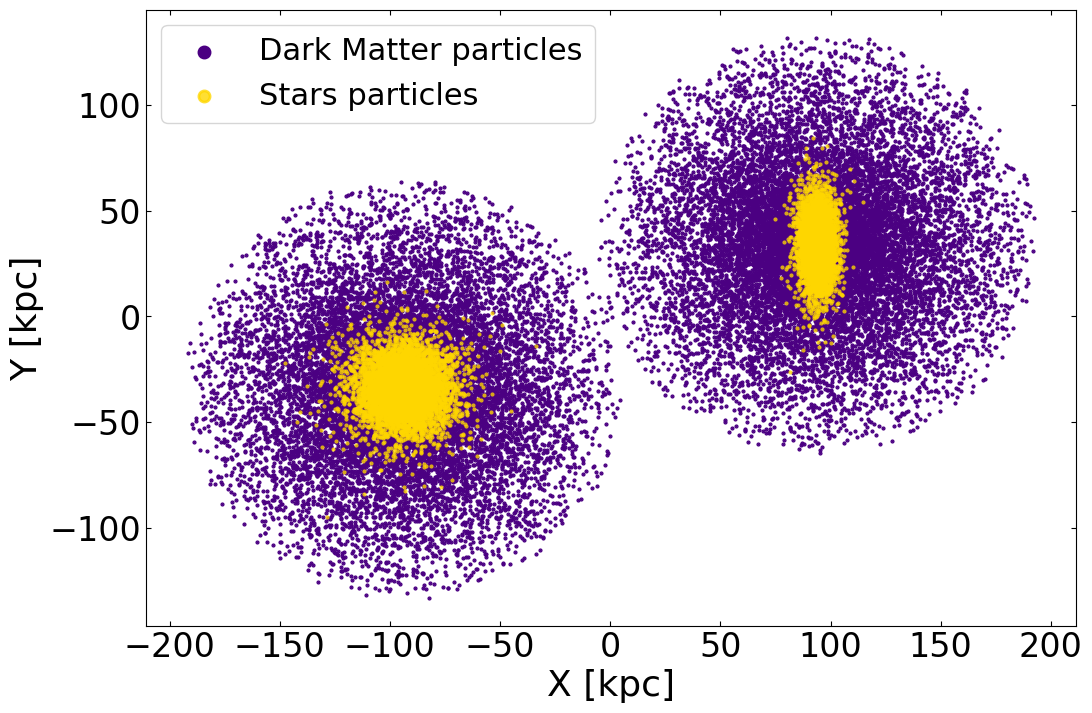

In [22]:
# Plot of the dm (type1) and stars (type2) particles
fig = plt.figure(figsize=(12, 8))
plt.scatter(xpos1, ypos1, color="indigo", s=1, linewidth=2, alpha=1, label="Dark Matter particles")
plt.scatter(xpos2, ypos2, color="gold", s=1, linewidth=2, alpha=0.8, label="Stars particles")
plt.tick_params(axis="both", which="both", direction="in", labelsize=24, top=True, right=True, left=True, bottom=True)
plt.xlabel("X [kpc]", fontsize=26)
plt.ylabel("Y [kpc]", fontsize=26)
plt.legend(markerscale=8, fontsize=22)
plt.savefig("dm_and_stars_positioning.pdf", dpi=300)
#plt.tight_layout()